#  Análise Exploratória e Visualização de Dados (EDA)

> **Nota Metodológica:** 
> Na primeira parte deste notebook, exploramos e documentamos as visualizações utilizando bibliotecas estatísticas tradicionais (`Matplotlib` e `Seaborn`), focando em gráficos estáticos com alto padrão visual para relatórios e apresentações corporativas. 
> 
> Na sequência, apresentaremos a versão interativa desses mesmos indicadores utilizando a biblioteca `Plotly`, permitindo exploração dinâmica de dados, *hover* detalhado e zoom.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Cria a pasta assets se nao existir
os.makedirs("assets", exist_ok=True)

# Determinando o estilo visual que usaremos (Seaborn) e o tamanho da fonte dos graficos (Matplotlib)
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

# Conexao com o MySQL (docker compose rodando)
load_dotenv()

USER = os.getenv('DB_USER')
PASSWORD = os.getenv('DB_PASSWORD')
HOST = os.getenv('DB_HOST')
PORT = os.getenv('DB_PORT')
DATABASE = os.getenv('DB_NAME')

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

### 1. Evolução Mensal de Pedidos Válidos (`evolucao_mensal_vendas.png`)
* **Objetivo:** Acompanhar a trajetória de crescimento do marketplace ao longo do tempo.
* **Insight:** Demonstra a evolução contínua das vendas a partir do piloto em **09/2016** até o pico de maturidade em **2018**, evidenciando também a ruptura e encerramento da coleta do dataset em **08/2018**.

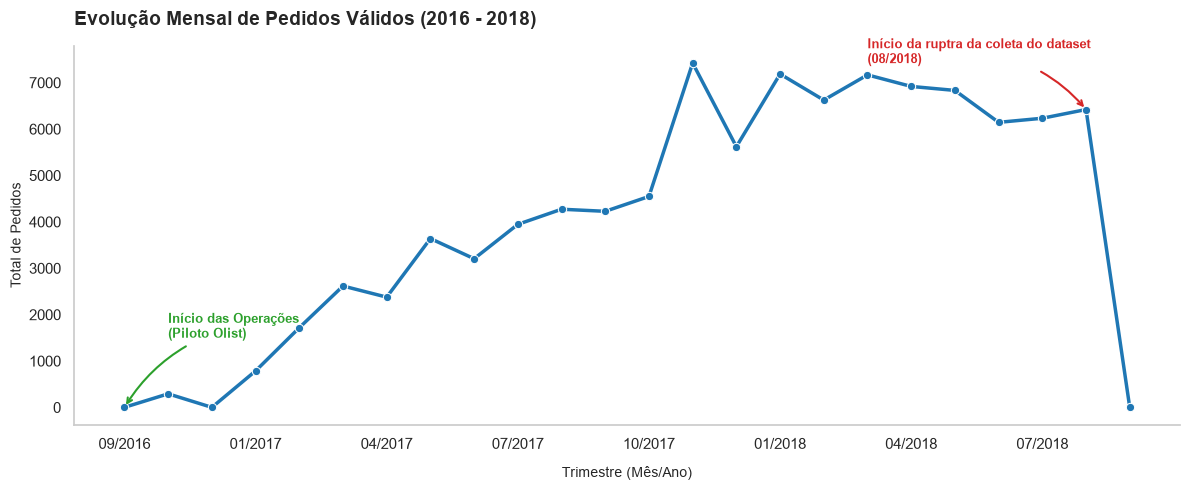

In [12]:

"""
 VAmos fazer a consulta sql para obter a evolução mensal de pedidos válidos (não cancelados e não indisponíveis) do dataset Olist.
 Depois, vamos plotar um gráfico de linha com marcadores para visualizar a evolução ao longo do tempo.
 Vamos também adicionar anotações para destacar eventos importantes, como o início das operações e o fim da coleta do dataset.
""" 


q_evolucao = """
SELECT 
    DATE_FORMAT(order_purchase_timestamp, '%%m/%%Y') AS mes_ano,
    COUNT(*) AS total_pedidos
FROM olist_orders_dataset
WHERE order_status NOT IN ('canceled', 'unavailable')
GROUP BY DATE_FORMAT(order_purchase_timestamp, '%%Y-%%m'), mes_ano
ORDER BY DATE_FORMAT(order_purchase_timestamp, '%%Y-%%m') ASC;
"""

df_evolucao = pd.read_sql(q_evolucao, con=engine)

# Configuracao da figura que irá conter o gráfico
fig, ax = plt.subplots(figsize=(12, 5))

# Plot do gráfico de linha com marcadores
sns.lineplot(
    data=df_evolucao, 
    x='mes_ano', 
    y='total_pedidos', 
    color='#1f77b4', 
    linewidth=2.5,
    marker='o',
    markersize=6,
    ax=ax
)

# Desativa a grade do fundo e remove bordas superior/direita
ax.grid(False)
sns.despine(top=True, right=True)

# Uma grande qqualidade do gráfico é que ele tem muitos pontos no eixo x, então vamos mostrar apenas os rótulos trimestrais (a cada 3 meses) - tempo usado em análises de negócios
indices_trimestrais = list(range(0, len(df_evolucao), 3))
rotulos_trimestrais = df_evolucao['mes_ano'].iloc[indices_trimestrais]
plt.xticks(ticks=indices_trimestrais, labels=rotulos_trimestrais, rotation=0)

# Titulo e rotulos alinhados a esquerda
plt.title(
    "Evolução Mensal de Pedidos Válidos (2016 - 2018)", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("Trimestre (Mês/Ano)", fontsize=10, labelpad=10)
plt.ylabel("Total de Pedidos", fontsize=10)

# 1. Anotacao 1: Inicio das Operacoes (9/2016) - importante mostramos o início das operações do Olist.
idx_inicio = df_evolucao[df_evolucao['mes_ano'] == '09/2016'].index[0]
y_inicio = df_evolucao.loc[idx_inicio, 'total_pedidos']

ax.annotate(
    "Início das Operações\n(Piloto Olist)",
    xy=(idx_inicio, y_inicio),
    xytext=(idx_inicio + 1, y_inicio + 1500),
    arrowprops=dict(
        facecolor='#2ca02c',
        edgecolor='#2ca02c',
        arrowstyle="->",
        lw=1.5,
        connectionstyle="arc3,rad=0.2"
    ),
    fontsize=9,
    fontweight="bold",
    color="#2ca02c"
)

# 2. Anotacao: Fim da Coleta do Dataset (08/2018)
idx_fim = df_evolucao[df_evolucao['mes_ano'] == '08/2018'].index[0]
y_fim = df_evolucao.loc[idx_fim, 'total_pedidos']

ax.annotate(
    "Início da ruptra da coleta do dataset\n(08/2018)",
    xy=(idx_fim, y_fim),
    xytext=(idx_fim - 5, y_fim + 1000),
    arrowprops=dict(
        facecolor='#d62728',
        edgecolor='#d62728',
        arrowstyle="->",
        lw=1.5,
        connectionstyle="arc3,rad=-0.2"
    ),
    fontsize=9,
    fontweight="bold",
    color="#d62728"
)

plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/evolucao_mensal_vendas.png", dpi=300)
plt.show()

### 2. Taxa de Atraso na Entrega por Estado (`atraso_por_estado.png`)
* **Objetivo:** Identificar os gargalos logísticos regionais no cumprimento dos prazos prometidos aos clientes.
* **Insight:** Destaca estados com taxas de atraso elevadas (superiores a **12%**), com ênfase no **Rio de Janeiro** e regiões do **Nordeste**, em comparação com a média das demais UFs.

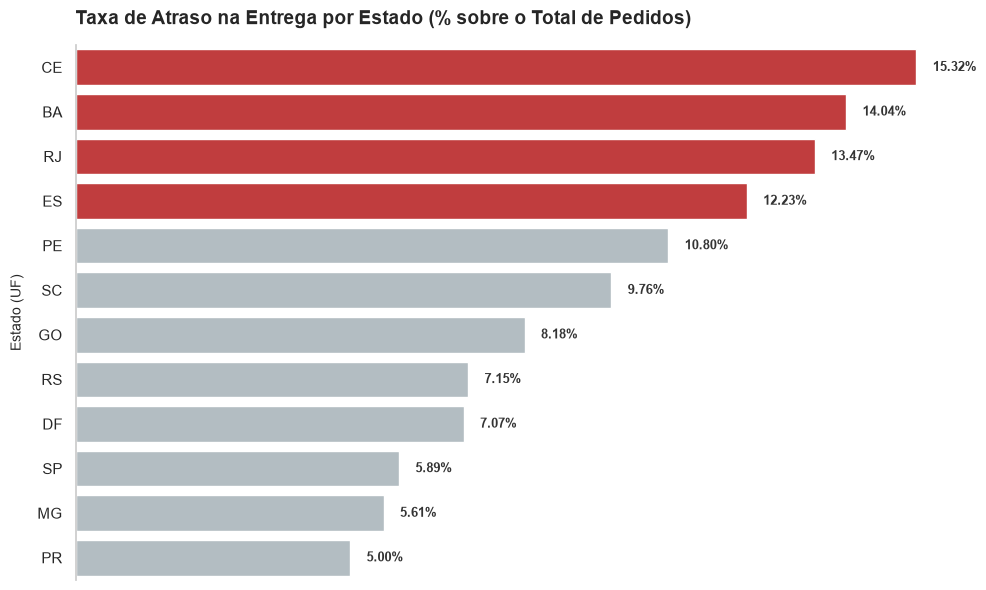

In [20]:
q_atraso_uf = """
SELECT 
    c.customer_state AS uf,
    ROUND(SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_atraso
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
HAVING COUNT(o.order_id) >= 1000
ORDER BY pct_atraso DESC;
"""

df_atraso_uf = pd.read_sql(q_atraso_uf, con=engine)

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Cores: Destaca piores estados (>= 12%) em vermelho e o restante em cinza
cores = ['#d62728' if x >= 12.0 else '#b0bec5' for x in df_atraso_uf['pct_atraso']]

# Plot de barras horizontais (com hue e legend=False)
sns.barplot(
    data=df_atraso_uf, 
    x='pct_atraso', 
    y='uf', 
    hue='uf',
    legend=False,
    palette=cores,
    ax=ax
)

# Limpeza estética
ax.grid(False)
sns.despine(top=True, right=True, bottom=True)

# Remove o eixo X inferior para evitar poluição
ax.set_xticks([])

# Título e rótulos alinhados à esquerda
plt.title(
    "Taxa de Atraso na Entrega por Estado (% sobre o Total de Pedidos)", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("")
plt.ylabel("Estado (UF)", fontsize=10, labelpad=10)

# Adiciona o valor exato na ponta de cada barra
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(
        f"{largura:.2f}%",
        xy=(largura + 0.3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/atraso_por_estado.png", dpi=300)
plt.show()

### 3. Impacto do Atraso no CSAT / Review Score (`impacto_atraso_csat.png`)
* **Objetivo:** Analisar como o descumprimento do prazo de entrega afeta a satisfação e percepção do cliente.
* **Insight:** Evidencia a forte correlação entre logística e satisfação: **quase 50% dos clientes afetados por atraso atribuem Nota 1 (detratores)**, enquanto entregas no prazo concentram sua maioria absoluta na Nota 5.

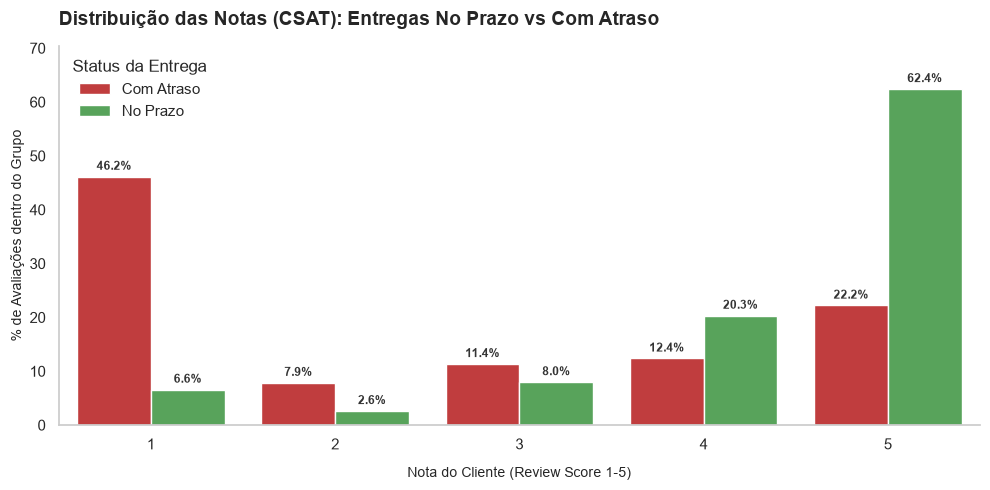

In [19]:
# Query simplificada sem nenhuma porcentagem ou CTE complexa
q_csat_atraso = """
SELECT 
    CASE 
        WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 'No Prazo'
        ELSE 'Com Atraso'
    END AS status_entrega,
    r.review_score AS nota,
    COUNT(*) AS total_avaliacoes
FROM olist_orders_dataset o
JOIN olist_order_reviews_dataset r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY status_entrega, nota
ORDER BY status_entrega, nota;
"""

# Executa a query
df_csat = pd.read_sql(q_csat_atraso, con=engine)

# Calcula o percentual dentro de cada grupo (No Prazo vs Com Atraso) via Pandas
df_csat['total_grupo'] = df_csat.groupby('status_entrega')['total_avaliacoes'].transform('sum')
df_csat['pct_avaliacoes'] = (df_csat['total_avaliacoes'] / df_csat['total_grupo']) * 100

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 5))

# Plot das barras agrupadas
sns.barplot(
    data=df_csat,
    x='nota',
    y='pct_avaliacoes',
    hue='status_entrega',
    palette={'No Prazo': '#4caf50', 'Com Atraso': '#d62728'},
    ax=ax
)

# Limpeza visual
ax.grid(False)
sns.despine(top=True, right=True)

# Título e rótulos alinhados à esquerda
plt.title(
    "Distribuição das Notas (CSAT): Entregas No Prazo vs Com Atraso", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("Nota do Cliente (Review Score 1-5)", fontsize=10, labelpad=10)
plt.ylabel("% de Avaliações dentro do Grupo", fontsize=10)
plt.legend(title="Status da Entrega", frameon=False)

# Adiciona os rótulos de porcentagem em cima das barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f"{altura:.1f}%",
            xy=(p.get_x() + p.get_width() / 2, altura + 0.8),
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold',
            color='#333333'
        )

# Ajusta limite do eixo Y para evitar cortes nos rótulos
ax.set_ylim(0, max(df_csat['pct_avaliacoes']) + 8)

plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/impacto_atraso_csat.png", dpi=300)
plt.show()

### 4. Concentração Geográfica de Volume e Receita (`pedidos_receita_por_estado.png`)
* **Objetivo:** Mapear a representatividade de cada estado na receita total (*GMV*) e no volume de pedidos do e-commerce.
* **Insight:** Revela a forte dependência operacional e financeira do **Sudeste** (com liderança isolada de SP e RJ), consolidando a região como o principal polo consumidor da plataforma.

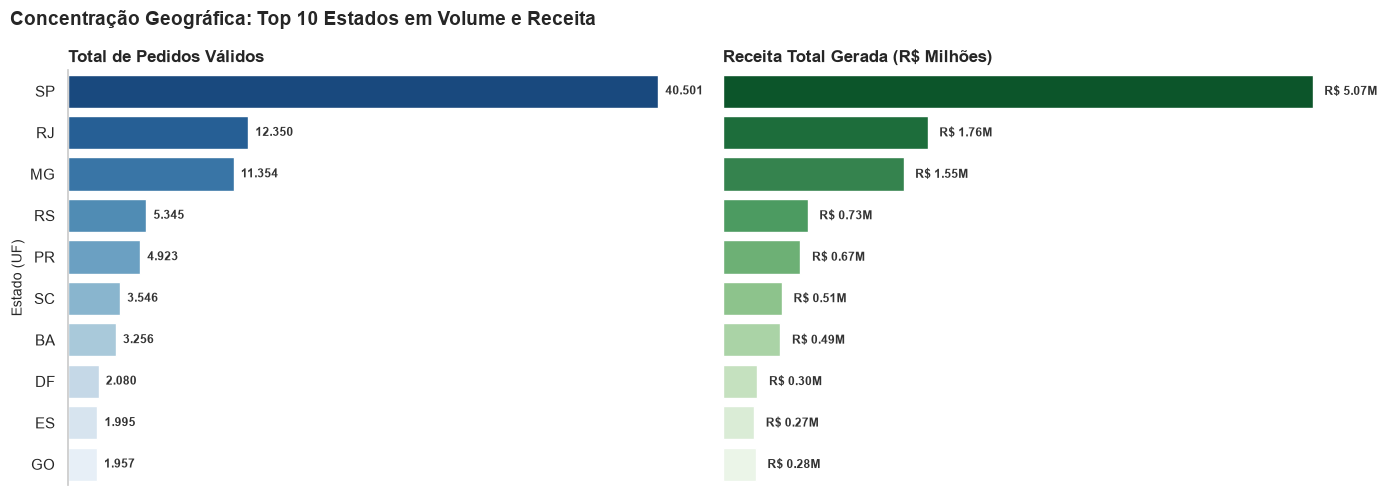

In [21]:
# Query para agrupar pedidos e receita por estado do cliente
q_locais_receita = """
SELECT 
    c.customer_state AS uf,
    COUNT(DISTINCT o.order_id) AS total_pedidos,
    ROUND(SUM(i.price), 2) AS receita_total
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_order_items_dataset i ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_pedidos DESC
LIMIT 10;
"""

df_locais = pd.read_sql(q_locais_receita, con=engine)

# Configuração da figura com 2 subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1. Gráfico de Pedidos
sns.barplot(
    data=df_locais, 
    x='total_pedidos', 
    y='uf', 
    hue='uf', 
    legend=False, 
    palette='Blues_r', 
    ax=ax1
)
ax1.set_title("Total de Pedidos Válidos", fontsize=12, fontweight="bold", loc="left")
ax1.set_xlabel("")
ax1.set_ylabel("Estado (UF)", fontsize=10)
ax1.grid(False)
sns.despine(top=True, right=True, bottom=True, ax=ax1)
ax1.set_xticks([])

for p in ax1.patches:
    largura = p.get_width()
    ax1.annotate(
        f"{int(largura):,}".replace(",", "."),
        xy=(largura + 500, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=8.5, fontweight='bold', color='#333333'
    )

# 2. Gráfico de Receita (em Milhões de R$)
df_locais['receita_milhoes'] = df_locais['receita_total'] / 1_000_000

sns.barplot(
    data=df_locais, 
    x='receita_milhoes', 
    y='uf', 
    hue='uf', 
    legend=False, 
    palette='Greens_r', 
    ax=ax2
)
ax2.set_title("Receita Total Gerada (R$ Milhões)", fontsize=12, fontweight="bold", loc="left")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.grid(False)
sns.despine(top=True, right=True, bottom=True, left=True, ax=ax2)
ax2.set_xticks([])

for p in ax2.patches:
    largura = p.get_width()
    ax2.annotate(
        f"R$ {largura:.2f}M",
        xy=(largura + 0.1, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=8.5, fontweight='bold', color='#333333'
    )

plt.suptitle("Concentração Geográfica: Top 10 Estados em Volume e Receita", fontsize=14, fontweight="bold", x=0.01, ha='left')
plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/pedidos_receita_por_estado.png", dpi=300)
plt.show()

### 5. Participação do Top 5 Categorias por Região (`top_categorias_por_regiao.png`)
* **Objetivo:** Comparar o perfil e a proporção de demanda por tipo de produto entre as diferentes regiões do país.
* **Insight:** Permite avaliar a homogeneidade do consumo nacional nas categorias líderes (*Cama Mesa Banho*, *Beleza Saúde*, *Esporte Lazer*, etc.), neutralizando a disparidade de volume bruto do Sudeste.

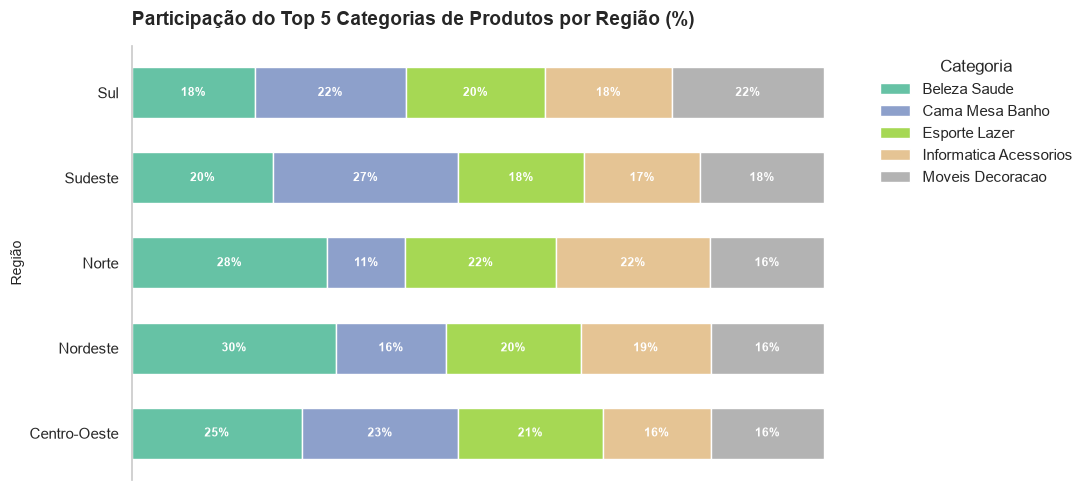

In [24]:
# Query para buscar a contagem por UF e Categoria
q_cat_regiao = """
SELECT 
    c.customer_state AS uf,
    p.product_category_name AS categoria,
    COUNT(*) AS total_itens
FROM olist_order_items_dataset i
JOIN olist_orders_dataset o ON i.order_id = o.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_products_dataset p ON i.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL
GROUP BY c.customer_state, p.product_category_name;
"""

df_cat = pd.read_sql(q_cat_regiao, con=engine)

# Mapeamento de UF para Região
mapa_regioes = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 
    'PB': 'Nordeste', 'RN': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste', 'PI': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'TO': 'Norte', 'AC': 'Norte', 'AP': 'Norte', 'RR': 'Norte'
}

df_cat['regiao'] = df_cat['uf'].map(mapa_regioes)

# Seleciona as 5 categorias mais vendidas do Brasil
top5_categorias = (
    df_cat.groupby('categoria')['total_itens']
    .sum()
    .nlargest(5)
    .index
)

# Filtra apenas o Top 5 e agrupa por Região
df_top5 = df_cat[df_cat['categoria'].isin(top5_categorias)].copy()
df_top5['categoria_limpa'] = df_top5['categoria'].str.replace('_', ' ').str.title()

# Cria matriz de porcentagem (100% por região)
pivot_counts = df_top5.pivot_table(
    index='regiao', 
    columns='categoria_limpa', 
    values='total_itens', 
    aggfunc='sum', 
    fill_value=0
)

# Converte para proporção (0 a 100%)
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

# Plotagem do gráfico de barras empilhadas 100%
fig, ax = plt.subplots(figsize=(11, 5))

pivot_pct.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    colormap='Set2', 
    width=0.6
)

# Limpeza e Estilização
ax.grid(False)
sns.despine(top=True, right=True, bottom=True)
ax.set_xticks([])  # Remove o eixo X numérico

plt.title(
    "Participação do Top 5 Categorias de Produtos por Região (%)", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("")
plt.ylabel("Região", fontsize=10)
plt.legend(title="Categoria", bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Adiciona o texto do percentual dentro de cada fatia do gráfico
for container in ax.containers:
    for rect in container:
        width = rect.get_width()
        if width > 5:  # Mostra o rótulo apenas se a fatia for grande o suficiente
            x_pos = rect.get_x() + width / 2
            y_pos = rect.get_y() + rect.get_height() / 2
            ax.annotate(
                f"{width:.0f}%",
                xy=(x_pos, y_pos),
                ha='center', 
                va='center', 
                fontsize=8.5, 
                fontweight='bold', 
                color='#ffffff'
            )

plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/top_categorias_por_regiao.png", dpi=300)
plt.show()

### 6. Preferência por Meios de Pagamento (`meios_de_pagamento.png`)
* **Objetivo:** Identificar as formas de pagamento predominantes no checkout dos clientes.
* **Insight:** Mostra a hegemonia do **Cartão de Crédito** (utilizado na maioria esmagadora das compras), seguido pelo **Boleto Bancário**, orientando estratégias financeiras e de integração de pagamentos.

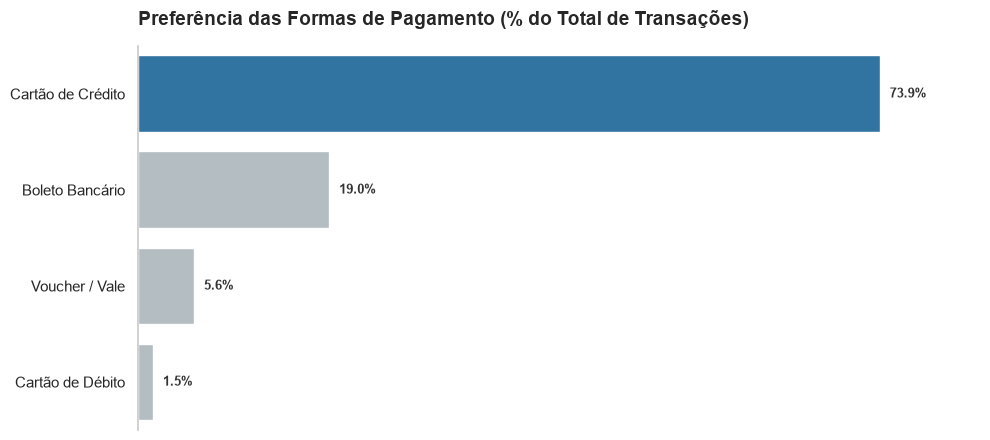

In [25]:
# Query para agrupar as formas de pagamento
q_pagamentos = """
SELECT 
    payment_type,
    COUNT(*) AS total_transacoes
FROM olist_order_payments_dataset
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY total_transacoes DESC;
"""

df_pag = pd.read_sql(q_pagamentos, con=engine)

# Ajusta nomes para exibicao executiva
mapeamento_pag = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto Bancário',
    'voucher': 'Voucher / Vale',
    'debit_card': 'Cartão de Débito'
}
df_pag['tipo_pagamento'] = df_pag['payment_type'].map(mapeamento_pag)

# Calcula o percentual
df_pag['pct_transacoes'] = (df_pag['total_transacoes'] / df_pag['total_transacoes'].sum()) * 100

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 4.5))

# Plot de barras horizontais
sns.barplot(
    data=df_pag,
    x='pct_transacoes',
    y='tipo_pagamento',
    hue='tipo_pagamento',
    legend=False,
    palette=['#1f77b4', '#b0bec5', '#b0bec5', '#b0bec5'],
    ax=ax
)

# Limpeza visual
ax.grid(False)
sns.despine(top=True, right=True, bottom=True)
ax.set_xticks([])

plt.title(
    "Preferência das Formas de Pagamento (% do Total de Transações)", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("")
plt.ylabel("")

# Adiciona o percentual e o valor absoluto no final de cada barra
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(
        f"{largura:.1f}%",
        xy=(largura + 1, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9, fontweight='bold', color='#333333'
    )

ax.set_xlim(0, max(df_pag['pct_transacoes']) + 10)
plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/meios_de_pagamento.png", dpi=300)
plt.show()

### 7. Tempo Médio de Entrega / Lead Time por Estado (`lead_time_por_estado.png`)
* **Objetivo:** Quantificar o tempo real (em dias) desde a confirmação da compra até a entrega no destino.
* **Insight:** Ilustra a dispersão do tempo de transporte no Brasil, onde entregas para estados mais distantes do Hub logístico chegam a superar **20 dias**, impactando diretamente o índice de satisfação do cliente.

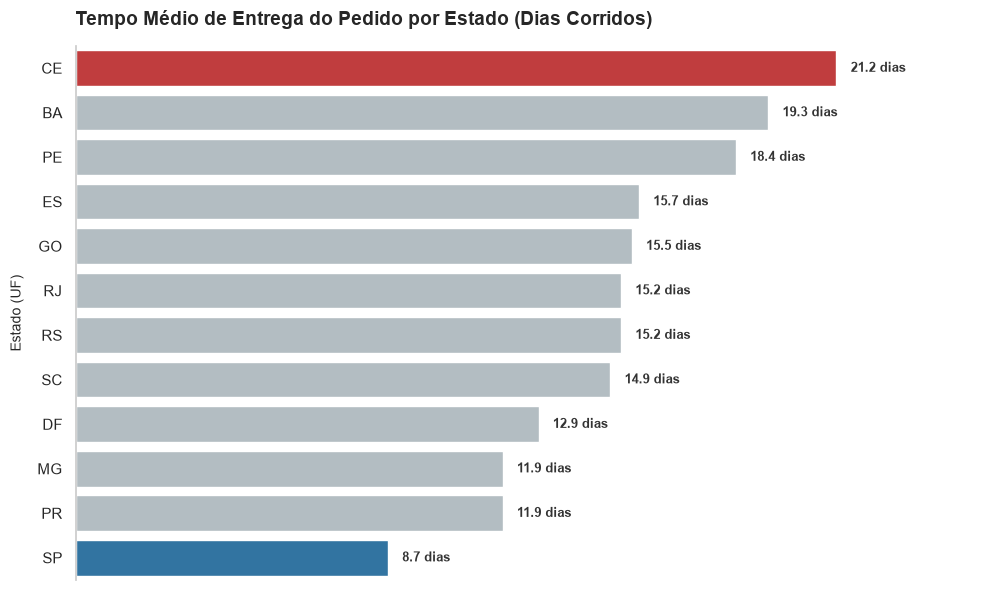

In [26]:
# Query para calcular a média de dias de entrega por estado
q_lead_time = """
SELECT 
    c.customer_state AS uf,
    ROUND(AVG(DATEDIFF(o.order_delivered_customer_date, o.order_purchase_timestamp)), 1) AS dias_medio_entrega
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
HAVING COUNT(o.order_id) >= 1000
ORDER BY dias_medio_entrega DESC;
"""

df_lead = pd.read_sql(q_lead_time, con=engine)

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Destaca os piores prazos (> 20 dias) em tom vermelho/alerta e os menores em azul
cores_lead = ['#d62728' if x >= 20.0 else '#1f77b4' if x <= 10.0 else '#b0bec5' for x in df_lead['dias_medio_entrega']]

sns.barplot(
    data=df_lead,
    x='dias_medio_entrega',
    y='uf',
    hue='uf',
    legend=False,
    palette=cores_lead,
    ax=ax
)

# Limpeza visual
ax.grid(False)
sns.despine(top=True, right=True, bottom=True)
ax.set_xticks([])

plt.title(
    "Tempo Médio de Entrega do Pedido por Estado (Dias Corridos)", 
    fontsize=14, 
    fontweight="bold", 
    loc="left", 
    pad=15
)
plt.xlabel("")
plt.ylabel("Estado (UF)", fontsize=10, labelpad=10)

# Adiciona o rótulo de dias na ponta das barras
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(
        f"{largura:.1f} dias",
        xy=(largura + 0.4, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9, fontweight='bold', color='#333333'
    )

ax.set_xlim(0, max(df_lead['dias_medio_entrega']) + 4)
plt.tight_layout()

# Salvar e exibir
plt.savefig("assets/lead_time_por_estado.png", dpi=300)
plt.show()